<a href="https://colab.research.google.com/github/evkoff/DI-Bootcamp-Stage1/blob/main/Week9/Day2/DailyChallenge/Week9Day2_DailyChallenge_Statistics_for_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [ ]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [ ]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
file_1 = "Churn_Modelling.csv"

In [ ]:
## TODO : make into a dataframe called df
df = pd.read_csv(file_1)

In [ ]:
## TODO : output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

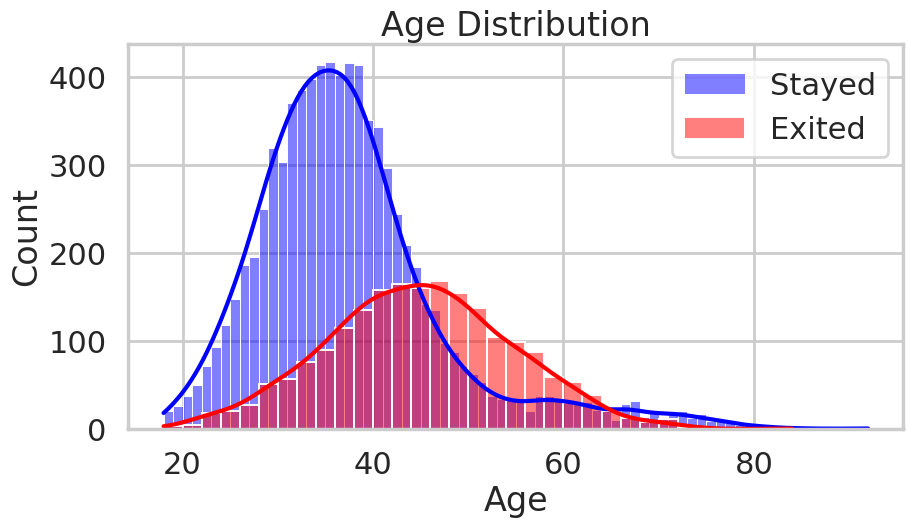

In [ ]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
plt.figure(figsize=(10,5))

sns.histplot(df_0['Age'],
             color='blue',
             label='Stayed',
             kde=True)

sns.histplot(df_1['Age'],
             color='red',
             label='Exited',
             kde=True)

plt.legend()
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

In [ ]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
mean_age_0 = df_0['Age'].mean()
std_age_0 = df_0['Age'].std()

print("Mean Age:", mean_age_0)
print("Std Age:", std_age_0)

Mean Age: 37.40838879819164
Std Age: 10.125362911047631


In [ ]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.
mean_age_1 = df_1['Age'].mean()
std_age_1 = df_1['Age'].std()

print("Mean Age:", mean_age_1)
print("Std Age:", std_age_1)

Mean Age: 44.8379970544919
Std Age: 9.761561555507132


In [ ]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.
t_stat, p_value = scipy.stats.ttest_ind(
    df_0['Age'],
    df_1['Age']
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

T-statistic: -29.76681499437077
P-value: 1.2399313093427736e-186
Reject H0


### Using Bootstrapping

In [ ]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(
          data,
          size=len(data),
          replace=True
      )
        bs_s[i] = func(bs_abc)
    return bs_s

In [ ]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
mean_diff = df_1['Age'].mean() - df_0['Age'].mean()

combined_mean = np.mean(
    np.concatenate([df_0['Age'], df_1['Age']])
)
age_0_shifted = df_0['Age'] - df_0['Age'].mean() + combined_mean
age_1_shifted = df_1['Age'] - df_1['Age'].mean() + combined_mean

In [ ]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
bs_0 = bs_choice(age_0_shifted, np.mean, 10000)
bs_1 = bs_choice(age_1_shifted, np.mean, 10000)

bs_diff = bs_1 - bs_0

In [ ]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
p_value = np.mean(np.abs(bs_diff) >= np.abs(mean_diff))

print("Bootstrap p-value:", p_value)

Bootstrap p-value: 0.0


### Conclusion
Do we reject the Null Hypothesis ? Why ?
The average age of customers who exited the bank (44.84 years) is higher than that of customers who remained customers (37.41 years).

Both the t-test and bootstrap analysis produced extremely small p-values, indicating that the observed difference is highly unlikely to have occurred by chance.

Therefore, we reject the null hypothesis and conclude that there is a statistically significant difference in age between customers who stayed and customers who exited the bank.

This suggests that age is an important factor associated with customer churn, with older customers showing a higher likelihood of leaving the bank in this dataset.

## Hypothesis 2: Credit Score

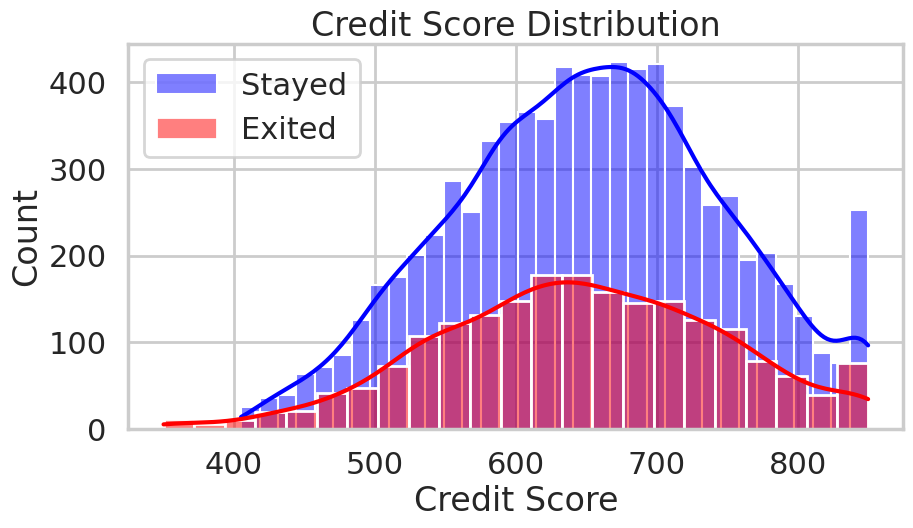

In [ ]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
plt.figure(figsize=(10,5))

sns.histplot(df_0['CreditScore'],
             color='blue',
             label='Stayed',
             kde=True)

sns.histplot(df_1['CreditScore'],
             color='red',
             label='Exited',
             kde=True)

plt.legend()
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.title('Credit Score Distribution')
plt.show()

In [ ]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).
print("Stayed mean:", df_0['CreditScore'].mean())
print("Exited mean:", df_1['CreditScore'].mean())

Stayed mean: 651.8531960316463
Exited mean: 645.3514972999509


In [ ]:
t_stat, p_value = scipy.stats.ttest_ind(
    df_0['CreditScore'],
    df_1['CreditScore']
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

T-statistic: 2.7100778888729833
P-value: 0.006738213892192373
Reject H0


### Conclusion
Do we reject the Null Hypothesis ? Why ?
The average Credit Score of customers who stayed with the bank (651.85) is slightly higher than that of customers who exited the bank (645.35).

The t-test produced a p-value of 0.0067, which is below the significance level of 0.05. Therefore, we reject the null hypothesis and conclude that there is a statistically significant difference in Credit Score between the two groups.

However, the difference in mean Credit Score is relatively small (approximately 6.5 points), suggesting that although Credit Score is associated with customer churn, its practical impact may be limited compared to other factors such as Age.

## Hypothesis 3: Balance

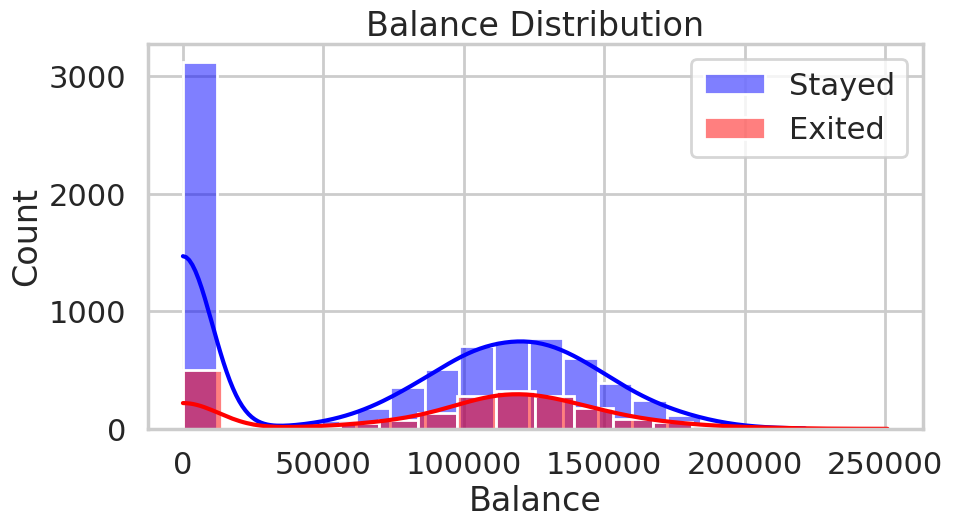

In [ ]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).
plt.figure(figsize=(10,5))

sns.histplot(df_0['Balance'],
             color='blue',
             label='Stayed',
             kde=True)

sns.histplot(df_1['Balance'],
             color='red',
             label='Exited',
             kde=True)

plt.legend()
plt.xlabel('Balance')
plt.ylabel('Count')
plt.title('Balance Distribution')
plt.show()

In [ ]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
print("Stayed mean:", df_0['Balance'].mean())
print("Exited mean:", df_1['Balance'].mean())

t_stat, p_value = scipy.stats.ttest_ind(
    df_0['Balance'],
    df_1['Balance']
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Stayed mean: 72745.2967788522
Exited mean: 91108.53933726068
T-statistic: -11.936240300013841
P-value: 1.2755633191525477e-32
Reject H0


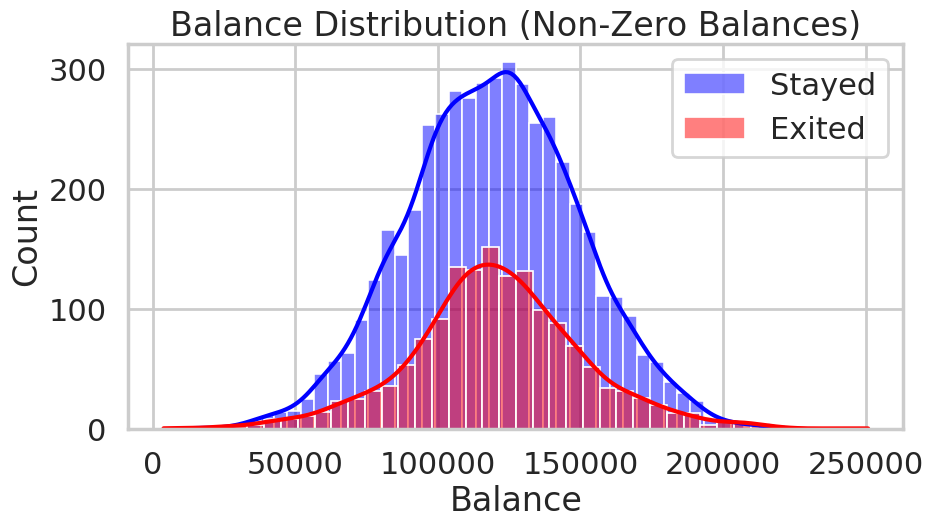

In [ ]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
df_0_nonzero = df_0[df_0['Balance'] > 0]
df_1_nonzero = df_1[df_1['Balance'] > 0]

plt.figure(figsize=(10,5))

sns.histplot(
    df_0_nonzero['Balance'],
    color='blue',
    label='Stayed',
    kde=True
)

sns.histplot(
    df_1_nonzero['Balance'],
    color='red',
    label='Exited',
    kde=True
)

plt.legend()
plt.xlabel('Balance')
plt.ylabel('Count')
plt.title('Balance Distribution (Non-Zero Balances)')
plt.show()

In [ ]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.
print("Stayed mean:", df_0_nonzero['Balance'].mean())
print("Exited mean:", df_1_nonzero['Balance'].mean())

t_stat, p_value = scipy.stats.ttest_ind(
    df_0_nonzero['Balance'],
    df_1_nonzero['Balance']
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Stayed mean: 119535.86426950061
Exited mean: 120746.97113207547
T-statistic: -1.374781881782122
P-value: 0.16924734893322796
Fail to Reject H0


## Conclusion

Do we reject the Null Hypothesis ? Why ?

When all customers were included, the average balance appeared significantly different between customers who stayed and customers who exited the bank. However, this result was heavily influenced by customers with zero balances.

After excluding customers with zero balances, the difference in average balance became very small (approximately 1,200), and the p-value increased to 0.169, which is above the significance threshold of 0.05.

Therefore, we fail to reject the null hypothesis. Among customers with non-zero balances, there is no statistically significant difference in balance between customers who stayed and customers who exited the bank.

This suggests that the initial difference was primarily driven by the presence of zero-balance accounts rather than by differences in the balances of active customers.

## Hypothesis 4: Estimated Salary

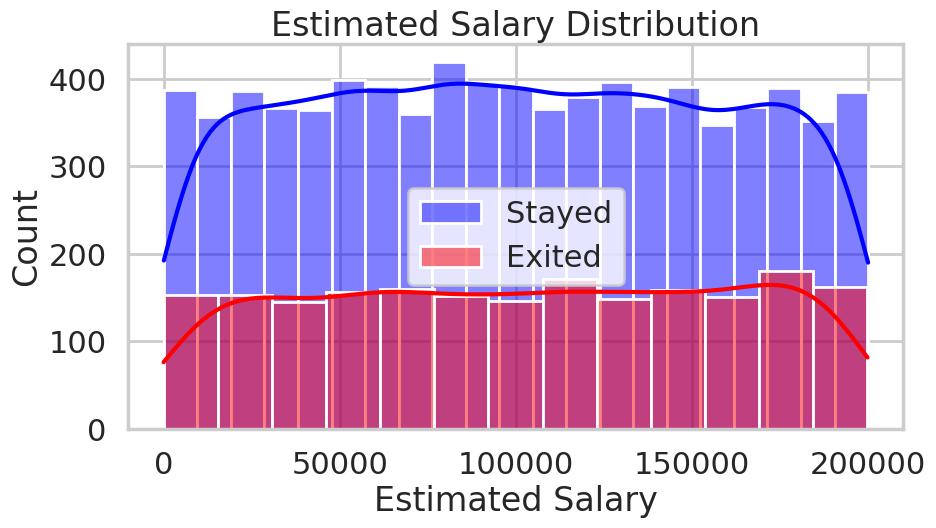

In [ ]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
plt.figure(figsize=(10,5))

sns.histplot(
    df_0['EstimatedSalary'],
    color='blue',
    label='Stayed',
    kde=True
)

sns.histplot(
    df_1['EstimatedSalary'],
    color='red',
    label='Exited',
    kde=True
)

plt.legend()
plt.xlabel('Estimated Salary')
plt.ylabel('Count')
plt.title('Estimated Salary Distribution')
plt.show()

In [ ]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
print("Stayed mean:", df_0['EstimatedSalary'].mean())
print("Exited mean:", df_1['EstimatedSalary'].mean())

t_stat, p_value = scipy.stats.ttest_ind(
    df_0['EstimatedSalary'],
    df_1['EstimatedSalary']
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Stayed mean: 99738.39177194524
Exited mean: 101465.67753068237
T-statistic: -1.209653638019264
P-value: 0.22644042802223352
Fail to Reject H0


The average estimated salary of customers who stayed with the bank (99,738) and customers who exited the bank (101,466) is very similar. The t-test resulted in a p-value of 0.226, which is greater than the significance level of 0.05. Therefore, we fail to reject the null hypothesis and conclude that there is no statistically significant difference in estimated salary between the two groups. Based on this dataset, estimated salary does not appear to be associated with customer churn.

### Using Bootstrapping

In [ ]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.

# calculate difference between means of 2 groups (between average salaries of the clients who left and the clients who stayed), so it's a real difference (as opposed to bs_diff that we will calculate later)
mean_diff = df_1['EstimatedSalary'].mean() - df_0['EstimatedSalary'].mean()

# concatenate 2 groups onto one big array and calculate mean among all clients
combined_mean = np.mean(
    np.concatenate([
        df_0['EstimatedSalary'],
        df_1['EstimatedSalary']
    ])
)

# shift both groups so that their mean will be equal to combined_mean, so we created a world where H0 is true
salary_0_shifted = (
    df_0['EstimatedSalary']
    - df_0['EstimatedSalary'].mean()
    + combined_mean
)

salary_1_shifted = (
    df_1['EstimatedSalary']
    - df_1['EstimatedSalary'].mean()
    + combined_mean
)

In [ ]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.
# do 1000 bootstrap - create 1000 small groups and calculate mean for each
bs_0 = bs_choice(
    salary_0_shifted,
    np.mean,
    10000
)

bs_1 = bs_choice(
    salary_1_shifted,
    np.mean,
    10000
)

# bootstrap distribution of the difference in means in order to answer the question - how often differences in means could occur accidantly if H0 is true
bs_diff = bs_1 - bs_0

In [ ]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.

p_value = np.mean(
    np.abs(bs_diff) >= np.abs(mean_diff)
)

print("Bootstrap p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Bootstrap p-value: 0.2317
Fail to Reject H0


### Conclusion
Do we reject the Null Hypothesis ? Why ?
The average estimated salary of customers who stayed with the bank (99,738) and customers who exited the bank (101,466) is very similar. Both the t-test and bootstrap analysis produced p-values greater than 0.05. Therefore, we fail to reject the null hypothesis and conclude that there is no statistically significant difference in estimated salary between the two groups. Based on this dataset, estimated salary does not appear to be associated with customer churn.

## Final Conclusion
What will be the most helpful feature in predicting churning?

Among the features analyzed, Age appears to be the most useful predictor of customer churn. Customers who exited the bank were significantly older on average than customers who remained with the bank, and this difference was confirmed by both the t-test and bootstrap analysis. Credit Score showed a statistically significant but relatively small difference, while Balance and Estimated Salary were not strong indicators of churn after further analysis. Therefore, Age is likely to be the most informative feature for predicting customer churn in this dataset.


## Machine learning classification model
### Data preparation

In [27]:
# Import libraries for machine learning
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns=['Exited', 'RowNumber', 'CustomerId', 'Surname'])
y = df['Exited']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (8000, 10)
Test set: (2000, 10)


### Preprocessing

In [28]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical features
categorical_features = ['Geography', 'Gender']

numerical_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary'
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

### Model creating and training - Logistic regression

In [29]:
# Import the classification model and pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create the complete machine learning pipeline
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

## Predict - Logistic regression

In [30]:
# Generate predictions for the test set
y_pred = model.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


## Model Evaluation - Logistic Regression

In [31]:
# Import classification metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.808
Precision: 0.5891472868217055
Recall: 0.18673218673218672
F1-score: 0.2835820895522388


### Confusion Matrix


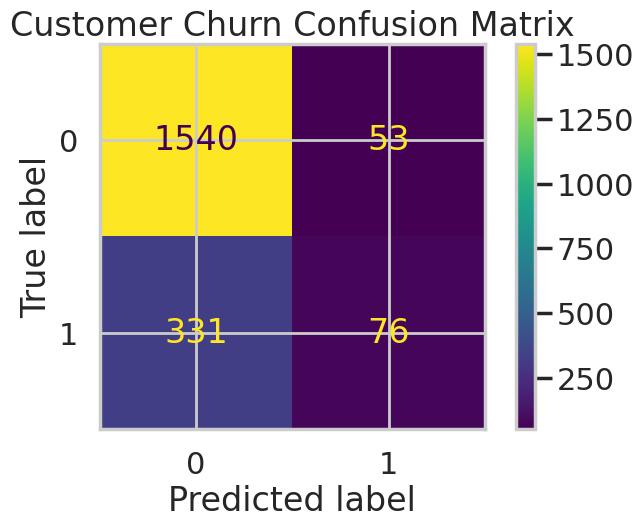

In [32]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Customer Churn Confusion Matrix")
plt.show()

### Model creating, training and prediction - Random Forest

In [33]:
# Import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest pipeline
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Generate predictions
rf_pred = rf_model.predict(X_test)

## Model Evaluation - Random Forest

In [34]:
# Calculate Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1-score:", rf_f1)

Random Forest Accuracy: 0.8565
Random Forest Precision: 0.75
Random Forest Recall: 0.44226044226044225
Random Forest F1-score: 0.5564142194744977


### Feature Importance Random Forest

In [35]:
# Get feature names after preprocessing
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance from the trained Random Forest
importances = rf_model.named_steps['classifier'].feature_importances_

# Create a DataFrame with feature names and their importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Display the most important features
print(feature_importance)

                   Feature  Importance
1                 num__Age    0.240208
7     num__EstimatedSalary    0.147592
0         num__CreditScore    0.142915
3             num__Balance    0.140873
4       num__NumOfProducts    0.125858
2              num__Tenure    0.084354
6      num__IsActiveMember    0.038166
9   cat__Geography_Germany    0.022192
5           num__HasCrCard    0.019452
8    cat__Geography_France    0.010725
10    cat__Geography_Spain    0.009737
12        cat__Gender_Male    0.009335
11      cat__Gender_Female    0.008594


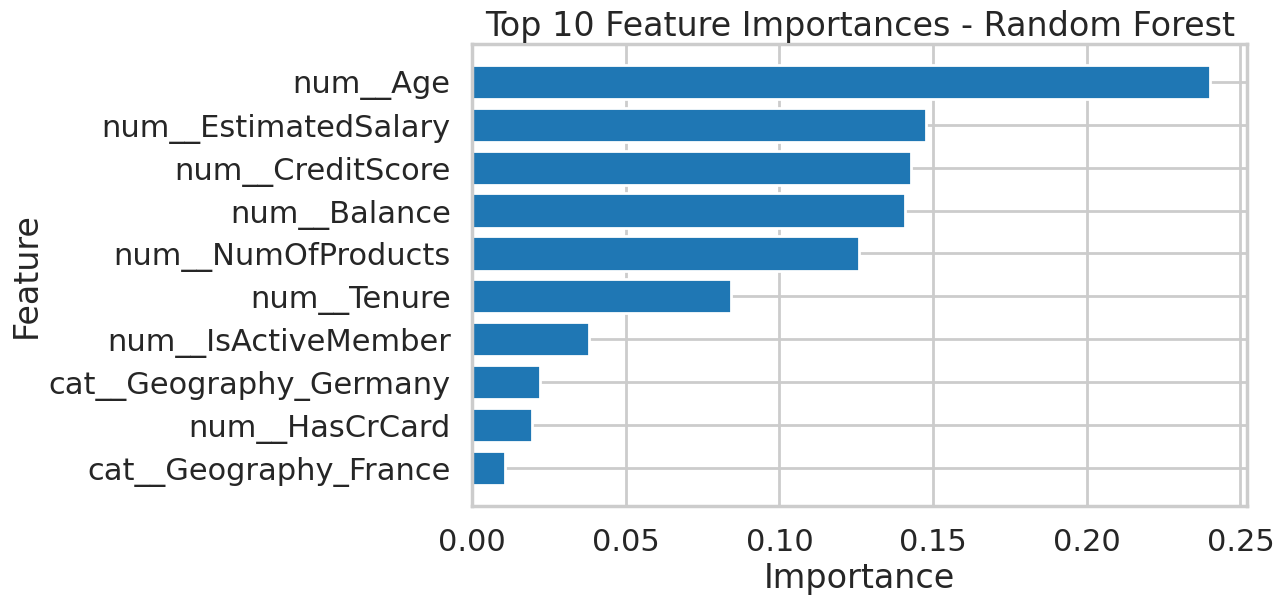

In [36]:
# Plot the top 10 most important features
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.show()

# Final Conclusion

Random Forest performed better than Logistic Regression for predicting customer churn, achieving 85.7% accuracy, 75.0% precision, 44.2% recall, and an F1-score of 55.6%.

Feature importance analysis showed that Age was the most important feature, followed by EstimatedSalary, CreditScore, Balance, and NumOfProducts. This is consistent with the earlier statistical analysis, which found a significant difference in age between customers who stayed and those who exited.

Overall, the Random Forest model provides a useful baseline for predicting customer churn, although its recall of 44.2% shows that further model improvement could help identify more customers at risk of leaving.